# Which MLB offensive metrics best predict winning?


## Key Findings

This analysis examined 300 team-seasons of MLB data from 2016–2025
to determine which offensive statistics best predict winning. The
results consistently favor on-base skills and comprehensive metrics
over traditional counting stats, with several findings that
challenge conventional baseball wisdom.

## Section 1: Introduction

The 2002 Oakland Athletics won 103 games despite having the MLB's third lowest payroll. They accomplished this by exploiting a free agent market where front offices overvalued certain offensive metrics. By acquiring players with high on-base percentages,the Athletics revolutionized the way we assess player performance. Fast forward 24 years, every MLB front office relies heavily on analytics. Has anything changed? This analysis will examine all 30 MLB teams from 2016 to 2025 to answer one question: which offensive metrics best predict winning? Front offices must choose carefully what skills to target in free agency, as it can make or break a team's season.

## Section 2: Data Collection

Using fangraphs, I will be examining all offensive team seasons from 2016 to 2025, as well as team standings.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
batting_data = pd.read_csv('Batting Data (2016-2025) - Sheet1.csv')
standings_data = pd.read_csv('MLB Standings 2016-2025 - Sheet1.csv')

## Section 3: Data Cleaning + Prep

In [13]:
print(batting_data.shape)
print(batting_data.head())
standings_data = standings_data[['Tm', 'W', 'L', 'W-L%', 'Year']]
standings_data = standings_data.rename(columns={'Tm': 'Team', 'W-L%': 'Win%', 'Year':'Season'})
print(standings_data.shape)
print(standings_data.head())


(300, 24)
   #  Season Team   TG     G    PA   HR    R  RBI   SB  ...    AVG    OBP  \
0  1    2019  HOU  162  2309  6394  288  920  891   67  ...  0.274  0.352   
1  2    2023  ATL  162  2278  6249  307  947  916  132  ...  0.276  0.344   
2  3    2022  LAD  162  2326  6247  212  847  812   98  ...  0.257  0.333   
3  4    2017  HOU  162  2313  6271  238  896  854   98  ...  0.282  0.346   
4  5    2023  TEX  162  2302  6306  233  881  845   79  ...  0.263  0.337   

     SLG   wOBA  xwOBA  wRC+  BsR    Off   Def   WAR  
0  0.495  0.355  0.338   124 -3.1  194.3  19.8  43.2  
1  0.501  0.359  0.364   126  9.5  208.8  -6.8  41.3  
2  0.442  0.337  0.334   119  9.0  147.9  -8.1  37.2  
3  0.478  0.349  0.335   121 -0.4  162.6  -1.0  36.7  
4  0.452  0.340  0.336   118 -8.4  126.6  11.0  35.2  

[5 rows x 24 columns]
(300, 5)
                    Team   W   L   Win%  Season
0      Milwaukee Brewers  97  65  0.599    2025
1  Philadelphia Phillies  96  66  0.593    2025
2      Toronto Blue J

In [14]:
full_to_abbr = {
    'Arizona Diamondbacks': 'ARI',
    'Athletics': 'ATH',
    'Atlanta Braves': 'ATL',
    'Baltimore Orioles': 'BAL',
    'Boston Red Sox': 'BOS',
    'Chicago Cubs': 'CHC',
    'Chicago White Sox': 'CHW',
    'Cincinnati Reds': 'CIN',
    'Cleveland Guardians': 'CLE',
    'Cleveland Indians': 'CLE',
    'Colorado Rockies': 'COL',
    'Detroit Tigers': 'DET',
    'Houston Astros': 'HOU',
    'Kansas City Royals': 'KCR',
    'Los Angeles Angels': 'LAA',
    'Los Angeles Dodgers': 'LAD',
    'Miami Marlins': 'MIA',
    'Milwaukee Brewers': 'MIL',
    'Minnesota Twins': 'MIN',
    'New York Mets': 'NYM',
    'New York Yankees': 'NYY',
    'Oakland Athletics': 'ATH',
    'Philadelphia Phillies': 'PHI',
    'Pittsburgh Pirates': 'PIT',
    'San Diego Padres': 'SDP',
    'San Francisco Giants': 'SFG',
    'Seattle Mariners': 'SEA',
    'St. Louis Cardinals': 'STL',
    'Tampa Bay Rays': 'TBR',
    'Texas Rangers': 'TEX',
    'Toronto Blue Jays': 'TOR',
    'Washington Nationals': 'WSN'
}

standings_data['Team'] = standings_data['Team'].map(full_to_abbr)
batting_data['Team'] = batting_data['Team'].replace('OAK', 'ATH')


In [15]:
data = batting_data.merge(standings_data[['Team', 'Season', 'W', 'L', 'Win%']], on=['Team', 'Season'])
data = data.drop(columns=['G', '#', 'Off', 'Def', 'W', 'L', 'WAR', 'HR', 'R', 'SB', 'RBI']) # Drops unnecessary columns
data['BB%'] = data['BB%'].str.replace('%', '').astype(float)
data['K%'] = data['K%'].str.replace('%', '').astype(float)
print(data.columns.tolist())


['Season', 'Team', 'TG', 'PA', 'BB%', 'K%', 'ISO', 'BABIP', 'AVG', 'OBP', 'SLG', 'wOBA', 'xwOBA', 'wRC+', 'BsR', 'Win%']


In [16]:
print(data.shape)
print(data.head())
print(data.describe())

(300, 16)
   Season Team   TG    PA   BB%    K%    ISO  BABIP    AVG    OBP    SLG  \
0    2019  HOU  162  6394  10.1  18.2  0.221  0.296  0.274  0.352  0.495   
1    2023  ATL  162  6249   8.6  20.6  0.225  0.306  0.276  0.344  0.501   
2    2022  LAD  162  6247   9.7  22.0  0.185  0.302  0.257  0.333  0.442   
3    2017  HOU  162  6271   8.1  17.3  0.196  0.309  0.282  0.346  0.478   
4    2023  TEX  162  6306   9.5  22.5  0.190  0.310  0.263  0.337  0.452   

    wOBA  xwOBA  wRC+  BsR   Win%  
0  0.355  0.338   124 -3.1  0.660  
1  0.359  0.364   126  9.5  0.642  
2  0.337  0.334   119  9.0  0.685  
3  0.349  0.335   121 -0.4  0.623  
4  0.340  0.336   118 -8.4  0.556  
           Season          TG           PA         BB%          K%  \
count   300.00000  300.000000   300.000000  300.000000  300.000000   
mean   2020.50000  151.760000  5737.933333    8.482667   22.465333   
std       2.87708   30.683557  1180.414281    0.990270    2.043801   
min    2016.00000   58.000000  2011.0

In [17]:
corr_cols = ['BB%', 'K%', 'ISO', 'BABIP', 'AVG', 'OBP', 'SLG', 'wOBA', 'xwOBA', 'wRC+', 'BsR', 'Win%']
corr = data[corr_cols].corr()['Win%'].drop('Win%').sort_values(ascending=False)
print(corr)

wRC+     0.726695
wOBA     0.678390
xwOBA    0.668646
OBP      0.666082
SLG      0.584230
ISO      0.561021
BB%      0.543623
AVG      0.403401
BsR      0.197156
BABIP    0.081876
K%      -0.304598
Name: Win%, dtype: float64


## Section 4: Exploratory Data Analysis: Which Stats Predict Winning?

### 1: Correlation between Offensive Statistics and Winning Percentage

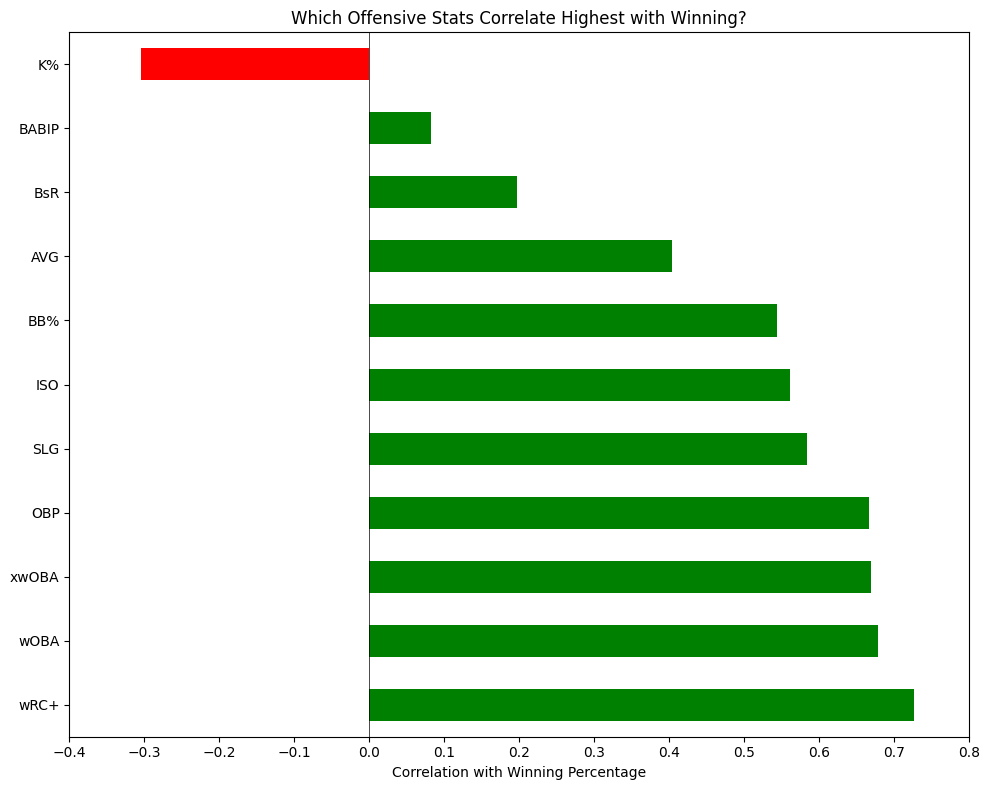

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Winning Percentage')
ax.set_title('Which Offensive Stats Correlate Highest with Winning?')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xticks(np.arange(-0.4, 0.9, 0.1))
plt.tight_layout()
plt.show()

### Takeaway
The strongest predictors of team wins are the all-in-one metrics
(wRC+, wOBA), followed by on-base skills (OBP, BB%). Batting average and baserunning value are notably weaker
predictors. To no surprise, strikeouts have a negative correlation with winning, though not as strong as expected.

### 2: Batting Average vs On Base Percentage


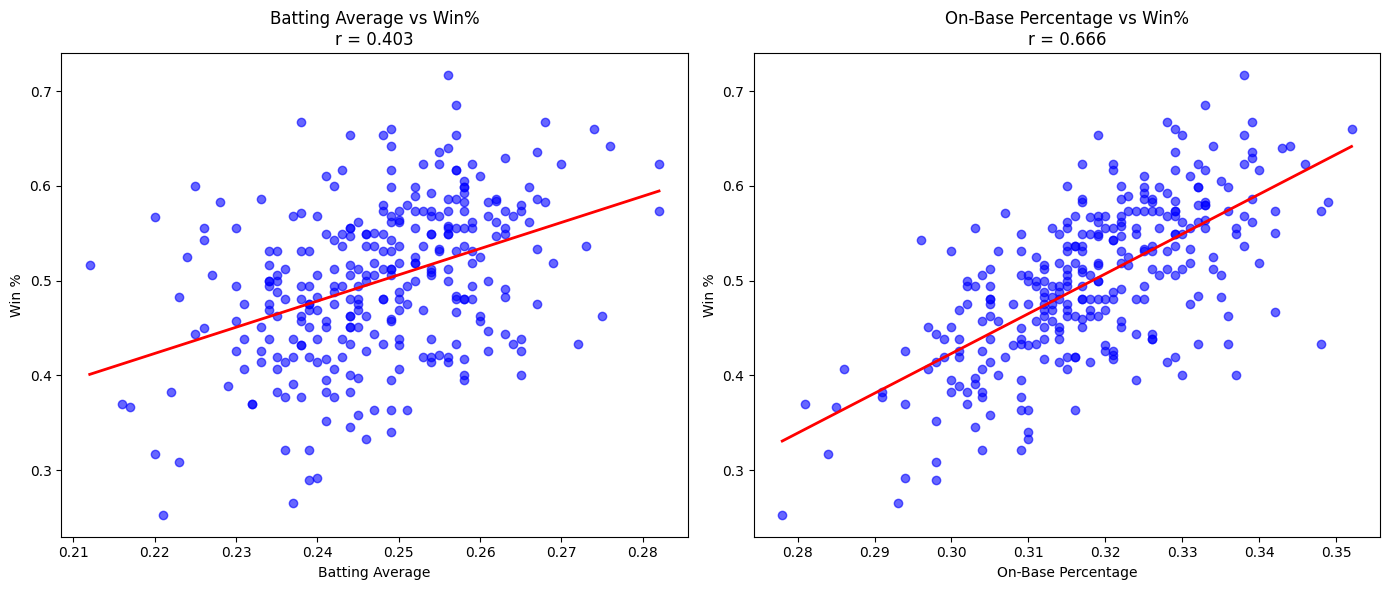

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AVG vs Win%
axes[0].scatter(data['AVG'], data['Win%'], color='blue', alpha=0.6)
z1 = np.polyfit(data['AVG'], data['Win%'], 1)
x1 = np.linspace(data['AVG'].min(), data['AVG'].max(), 100)
axes[0].plot(x1, np.poly1d(z1)(x1), color='red', linewidth=2)
r1 = data['AVG'].corr(data['Win%'])
axes[0].set_title(f'Batting Average vs Win%\nr = {r1:.3f}')
axes[0].set_xlabel('Batting Average')
axes[0].set_ylabel('Win %')

# OBP vs Win%
axes[1].scatter(data['OBP'], data['Win%'], color='blue', alpha=0.6)
z2 = np.polyfit(data['OBP'], data['Win%'], 1)
x2 = np.linspace(data['OBP'].min(), data['OBP'].max(), 100)
axes[1].plot(x2, np.poly1d(z2)(x2), color='red', linewidth=2)
r2 = data['OBP'].corr(data['Win%'])
axes[1].set_title(f'On-Base Percentage vs Win%\nr = {r2:.3f}')
axes[1].set_xlabel('On-Base Percentage')
axes[1].set_ylabel('Win %')

plt.tight_layout()
plt.show()

### Takeaway
OBP (r = 0.666) predicts team wins far better than batting average
(r = 0.403). Getting on base through walks, not just hits, remains
the more valuable skill even 20+ years after the original
Moneyball thesis.

### 3: Stat Correlations with Winning by Year

/tmp/ipykernel_4915/473604106.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = data.groupby('Season').apply(lambda x: x[stat].corr(x['Win%']))
/tmp/ipykernel_4915/473604106.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = data.groupby('Season').apply(lambda x: x[stat].corr(x['Win%']))
/tmp/ipykernel_4915/473604106.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the group

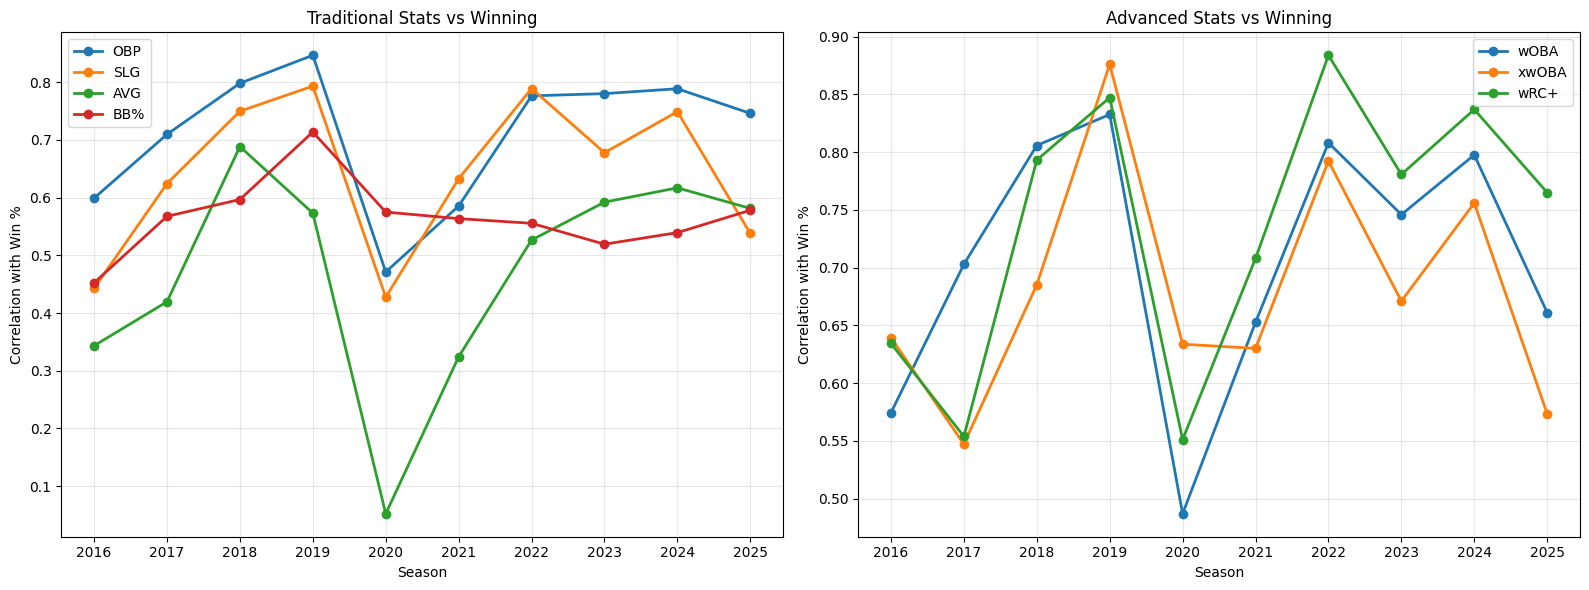

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Traditional stats
for stat in ['OBP', 'SLG', 'AVG', 'BB%']:
    yearly = data.groupby('Season').apply(lambda x: x[stat].corr(x['Win%']))
    axes[0].plot(yearly.index, yearly.values, marker='o', label=stat, linewidth=2)
axes[0].set_title('Traditional Stats vs Winning')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Correlation with Win %')
axes[0].set_xticks(range(2016, 2026))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Advanced stats
for stat in ['wOBA', 'xwOBA', 'wRC+']:
    yearly = data.groupby('Season').apply(lambda x: x[stat].corr(x['Win%']))
    axes[1].plot(yearly.index, yearly.values, marker='o', label=stat, linewidth=2)
axes[1].set_title('Advanced Stats vs Winning')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Correlation with Win %')
axes[1].set_xticks(range(2016, 2026))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways
- OBP is consistently the strongest single-stat predictor of winning across nearly every season
  
- AVG is consistently the weakest of the group, reinforcing that batting average is an overrated measure of offensive value

- All correlations dip in 2020 due to the shortened 60-game COVID
  season — small samples introduce more randomness

- wRC+ has emerged as the most reliable predictor of winning in
  recent seasons. Since 2021, wRC+ has consistently outperformed
  both wOBA and xwOBA, suggesting that adjusting for ballpark and
  league context captures something the raw weighted metrics miss.

- xwOBA's predictive power has dropped off significantly since 2022.
  Despite being based on "expected" outcomes using exit velocity and
  launch angle, xwOBA has underperformed actual wOBA in recent years.
  This suggests that what a team does with its batted balls matters
  more than what the physics says should happen.

### 4: K% Myth Buster

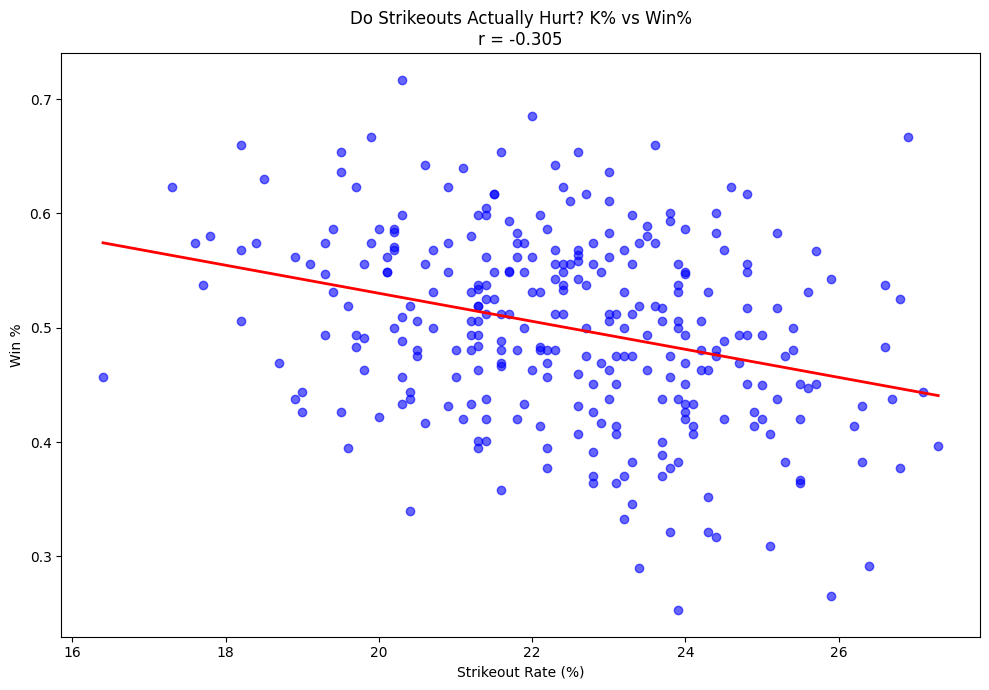

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(data['K%'], data['Win%'], color='blue', alpha=0.6)

z = np.polyfit(data['K%'], data['Win%'], 1)
x_line = np.linspace(data['K%'].min(), data['K%'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2)

r = data['K%'].corr(data['Win%'])
ax.set_title(f'Do Strikeouts Actually Hurt? K% vs Win%\nr = {r:.3f}')
ax.set_xlabel('Strikeout Rate (%)')
ax.set_ylabel('Win %')
plt.tight_layout()
plt.show()

### Takeaway
Conventional wisdom says strikeouts kill offenses, but the data
tells a different story. K% has only a weak negative correlation
with winning (r = -0.305). Teams that strike out a lot can still win
plenty of games — likely because the hitters who strike out more
also tend to hit for more power. This suggests that teams
shouldn't overpay for "contact hitters" at the expense of power
and on-base ability.

### 5: Outlier Teams

In [22]:
from sklearn.linear_model import LinearRegression

X = data[['wRC+']].values
y = data['Win%'].values

model = LinearRegression().fit(X, y)
data['Expected_Win%'] = model.predict(X)
data['Residual'] = data['Win%'] - data['Expected_Win%']

print("★ BIGGEST OVERPERFORMERS (Won more than offense suggests)")
print("  (Likely carried by pitching/defense)\n")
over = data.nlargest(10, 'Residual')[['Team', 'Season', 'Win%', 'Expected_Win%', 'wRC+']]
print(over.to_string(index=False))

print("\n★ BIGGEST UNDERPERFORMERS (Won less than offense suggests)")
print("  (Good offense wasted by bad pitching/defense)\n")
under = data.nsmallest(10, 'Residual')[['Team', 'Season', 'Win%', 'Expected_Win%', 'wRC+']]
print(under.to_string(index=False))

★ BIGGEST OVERPERFORMERS (Won more than offense suggests)
  (Likely carried by pitching/defense)

Team  Season  Win%  Expected_Win%  wRC+
 CLE    2020 0.583       0.452232    90
 MIL    2021 0.586       0.463821    92
 COL    2018 0.558       0.440643    88
 BOS    2017 0.574       0.458026    91
 LAD    2021 0.654       0.539151   105
 LAD    2017 0.642       0.533356   104
 CLE    2025 0.543       0.434848    87
 TEX    2016 0.586       0.481205    95
 SFG    2021 0.660       0.556535   108
 CHC    2020 0.567       0.463821    92

★ BIGGEST UNDERPERFORMERS (Won less than offense suggests)
  (Good offense wasted by bad pitching/defense)

Team  Season  Win%  Expected_Win%  wRC+
 NYM    2020 0.433       0.643454   123
 BAL    2018 0.290       0.434848    87
 WSN    2022 0.340       0.481205    95
 BOS    2020 0.400       0.539151   105
 BAL    2021 0.321       0.458026    91
 ATH    2023 0.309       0.440643    88
 WSN    2021 0.401       0.521767   102
 MIN    2016 0.364       0.481205

### Takeaway
The biggest overperformers won far more than their offense would
predict, suggesting elite pitching and defense can compensate for
an average lineup. Meanwhile, the underperformers show that even
a strong offense can't save a team with poor pitching.

This reinforces an important limitation of our analysis — offense
alone explains a lot of winning, but not all of it. A complete
model would need to incorporate pitching and defense as well.

## Section 5: Key Findings

1. **OBP predicts winning far better than batting average.**
   OBP correlated with Win% at r = 0.666 compared to AVG at
   r = 0.403. The original Moneyball thesis holds up with a
   decade of modern data.

2. **wRC+ is the single best offensive predictor of team wins**
   (r = 0.727), and has become increasingly dominant in recent
   seasons. Teams looking for one number to evaluate their
   offense should start here.

3. **Strikeouts are overrated as a negative.** K% showed only
   a weak negative correlation with winning (r = -0.305), suggesting
   teams shouldn't sacrifice power or on-base skills in pursuit
   of contact hitting.

4. **Offense alone doesn't tell the whole story.** Our outlier
   analysis revealed teams that significantly over- or
   under-performed their offensive stats, highlighting the
   importance of pitching and defense.

## What I'd Do Next
With more time, I would incorporate pitching and defensive metrics
to build a complete model of team wins, test whether these
relationships hold in the postseason where sample sizes shrink,
and use multiple regression to quantify exactly how many additional
wins each unit of OBP or SLG is worth.